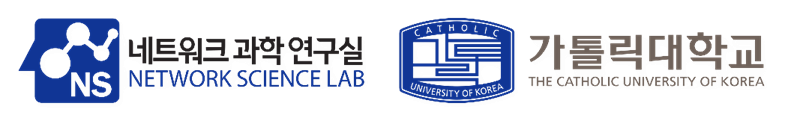

# 📊 Week 4: Towards Scalable Graph Neural Networks

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W4/SampleCode_4.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### A walkthrough of GraphSAGE and GraphSAINT

Large graphs rarely fit into one training batch. How can a model learn from only part of a graph at a time?

In this notebook, you will **see what gets sampled**, train two models on **Cora**, and interpret their results. Cora nodes represent papers, edges represent citation links, features describe words, and labels identify paper topics.





<a id="setup"></a>
## 1. Setup library

<!-- The installation cell is **opt-in**. For a fresh Python 3.10–3.12 CPU environment, set `INSTALL_DEPENDENCIES = True`, run it once, then restart the kernel and set it back to `False`.

This lesson keeps the original `NeighborSampler` API to expose the sampled adjacency blocks. It needs `torch-sparse` and `torch-cluster`, in addition to PyG. The pinned CPU recipe below keeps their binary builds aligned. For an existing CUDA environment, use the matching wheels in the [official PyG installation guide](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) instead of running this CPU recipe. -->


In [1]:
INSTALL_DEPENDENCIES = False

if INSTALL_DEPENDENCIES:
    import subprocess
    import sys

    def pip_install(*packages):
        subprocess.check_call([sys.executable, "-m", "pip", "install", *packages])

    pip_install("torch==2.8.0", "--index-url", "https://download.pytorch.org/whl/cpu")
    pip_install("torch-scatter", "torch-sparse", "torch-cluster",
                "--only-binary=:all:", "-f", "https://data.pyg.org/whl/torch-2.8.0+cpu.html")
    pip_install("torch-geometric==2.6.1", "numpy", "pandas", "matplotlib",
                "networkx", "scikit-learn", "ogb")
    print("Installation complete. Restart the kernel before continuing.")


In [2]:
from copy import deepcopy
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_cluster import random_walk
from torch_geometric.datasets import Planetoid
from torch_geometric.loader import NeighborSampler as RawNeighborSampler
from torch_geometric.loader import GraphSAINTRandomWalkSampler
from torch_geometric.nn import SAGEConv, GraphConv
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import degree

SEED = 42
DATA_ROOT = Path("data")  # Relative to the notebook kernel's working directory.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAGE_EPOCHS = 30
SAINT_EPOCHS = 30
HIDDEN_CHANNELS = 64
FANOUTS = [10, 10]
BATCH_SIZE = 256
SAINT_WALK_LENGTH = 2
SAINT_STEPS = 10
USE_SAINT_NORMALIZATION = False


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()
torch.set_num_threads(min(4, torch.get_num_threads()))
plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 10,
    "axes.titleweight": "bold", "font.size": 10,
    "axes.prop_cycle": plt.cycler(color=["#2563eb", "#d97706", "#059669", "#9333ea"]),
})
COLORS = {"train": "#2563eb", "validation": "#d97706", "test": "#059669"}
print(f"PyTorch {torch.__version__} | PyG {torch_geometric.__version__} | {DEVICE}")
print(f"Dataset cache: {DATA_ROOT.resolve()}")


PyTorch 2.8.0+cpu | PyG 2.6.1 | cpu
Dataset cache: /tmp/w4-notebook-run/data


<a id="explore"></a>
## 2. Meet the graph

A graph dataset is more than an adjacency matrix. Each row in `x` belongs to one node; each column in `edge_index` describes one directed connection; each entry in `y` is a class ID.

| Tensor | Shape | Meaning |
|:--|:--|:--|
| `x` | `[N, F]` | `F` input features for each of `N` nodes |
| `edge_index` | `[2, E]` | Source and destination indices for `E` stored edges |
| `y` | `[N]` | One integer topic label per node |
| `train_mask`, `val_mask`, `test_mask` | `[N]` | Which labels may be used at each stage |

We use Cora's public split and normalize each node's feature vector. Both experiments see the same graph and splits. **This is transductive learning:** all node features and edges are visible, but validation and test labels are excluded from training.


In [3]:
cora_dataset = Planetoid(root=str(DATA_ROOT / "Cora"), name="Cora",
                        split="public", transform=NormalizeFeatures())
cora = cora_dataset[0]
cora.y = cora.y.view(-1)  # Keep targets [N], even for datasets that return [N, 1].
NUM_CLASSES = cora_dataset.num_classes
CLASS_NAMES = [f"Topic {i}" for i in range(NUM_CLASSES)]

assert cora.y.ndim == 1
assert not (cora.train_mask & cora.val_mask).any()
assert not (cora.train_mask & cora.test_mask).any()
assert not (cora.val_mask & cora.test_mask).any()

summary = pd.DataFrame({
    "Quantity": ["Nodes", "Stored directed edges", "Features per node", "Classes",
                 "Training labels", "Validation labels", "Test labels"],
    "Value": [cora.num_nodes, cora.num_edges, cora.num_node_features, NUM_CLASSES,
              int(cora.train_mask.sum()), int(cora.val_mask.sum()), int(cora.test_mask.sum())],
})
display(summary.style.hide(axis="index").format({"Value": "{:,}"}))


Processing...


Done!


Quantity,Value
Nodes,"2,708"
Stored directed edges,"10,556"
Features per node,"1,433"
Classes,7
Training labels,140
Validation labels,500
Test labels,"1,000"


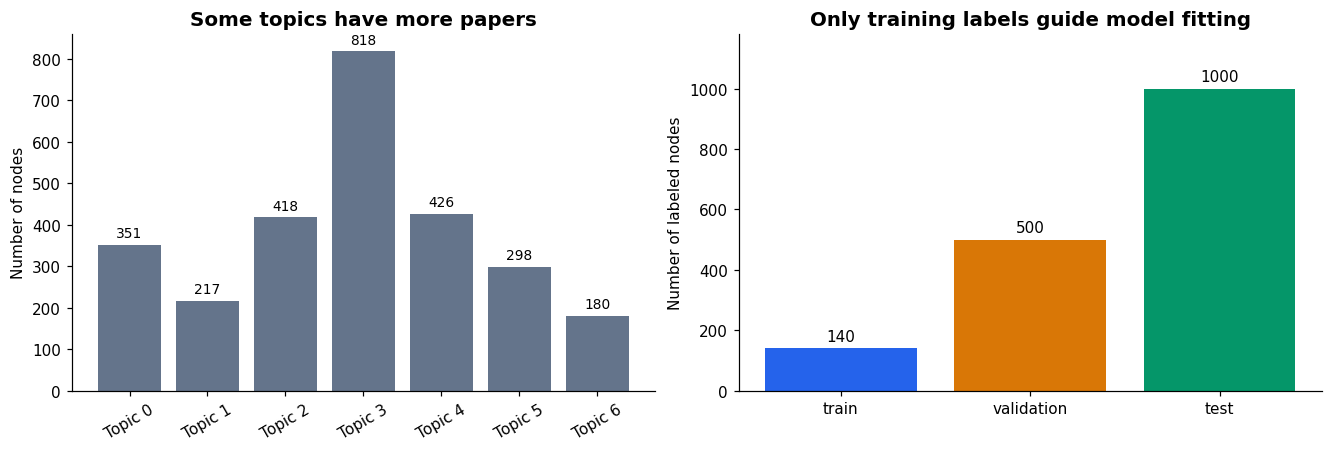

1,068 nodes belong to none of these labeled splits.


In [4]:
splits = {"train": cora.train_mask, "validation": cora.val_mask, "test": cora.test_mask}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
counts = np.bincount(cora.y.numpy(), minlength=NUM_CLASSES)
bars = axes[0].bar(CLASS_NAMES, counts, color="#64748b")
axes[0].bar_label(bars, padding=3, fontsize=9)
axes[0].set(title="Some topics have more papers", ylabel="Number of nodes")
axes[0].tick_params(axis="x", rotation=30)
split_counts = [int(mask.sum()) for mask in splits.values()]
bars = axes[1].bar(list(splits), split_counts, color=list(COLORS.values()))
axes[1].bar_label(bars, padding=3)
axes[1].set(title="Only training labels guide model fitting", ylabel="Number of labeled nodes")
axes[1].set_ylim(0, max(split_counts) * 1.18)
plt.show()
print(f"{cora.num_nodes - sum(split_counts):,} nodes belong to none of these labeled splits.")


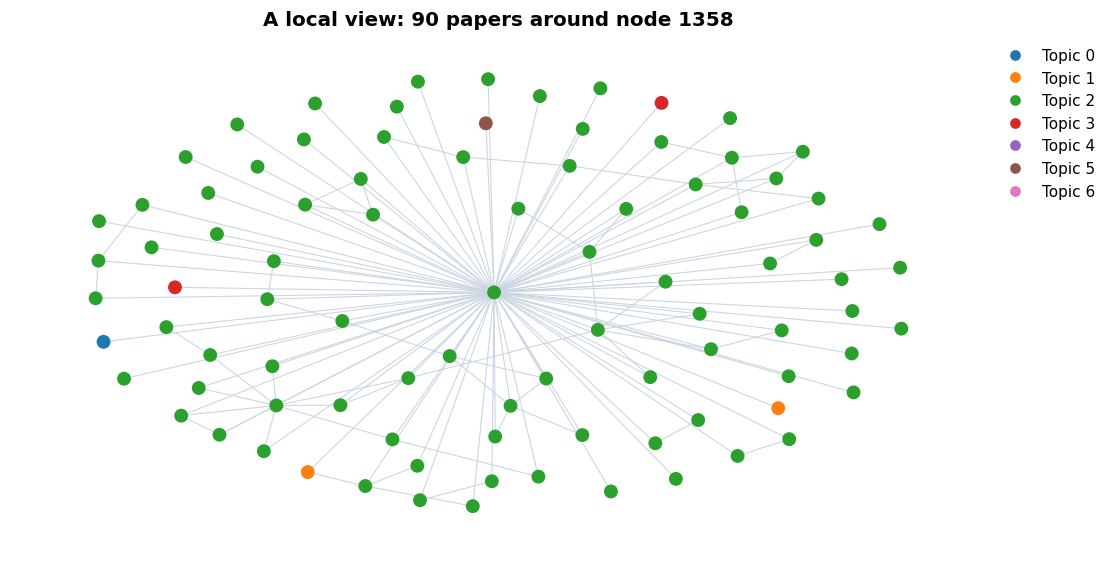

In [5]:
graph = nx.Graph()
graph.add_nodes_from(range(cora.num_nodes))
graph.add_edges_from(cora.edge_index.t().tolist())
center = max(graph, key=graph.degree)
visible_nodes = [center]
for _, node in nx.bfs_edges(graph, center):
    visible_nodes.append(node)
    if len(visible_nodes) >= 90:
        break
local_graph = graph.subgraph(visible_nodes)
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
node_colors = [int(cora.y[n]) for n in local_graph]
nx.draw_networkx(local_graph, pos=nx.spring_layout(local_graph, seed=SEED), ax=ax,
                 with_labels=False, node_size=65, node_color=node_colors,
                 cmap=plt.get_cmap("tab10"), vmin=0, vmax=9,
                 edge_color="#cbd5e1", width=0.7)
handles = [Line2D([0], [0], marker="o", linestyle="", label=name,
                  color=plt.get_cmap("tab10")(i)) for i, name in enumerate(CLASS_NAMES)]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
ax.set_title(f"A local view: {local_graph.number_of_nodes()} papers around node {center}")
ax.axis("off")
plt.show()


<a id="sampling"></a>
## 3 · Two ways to make a small training batch

**Neighbor sampling** starts from target nodes and samples a bounded number of neighbors at each layer. With fanouts `[10, 10]`, one target can draw on up to $1 + 10 + 10\times10 = 111$ node occurrences before accounting for overlap. These are limits, not guaranteed batch sizes.

**GraphSAINT random-walk sampling** starts walks at sampled nodes, collects the visited nodes, and keeps the original edges between those nodes. All model layers operate on that sampled subgraph. `batch_size` counts walk roots, so it is **not** the final number of unique nodes.

The diagrams below use the same toy graph and layout. They illustrate sampling mechanics, not a real Cora batch.


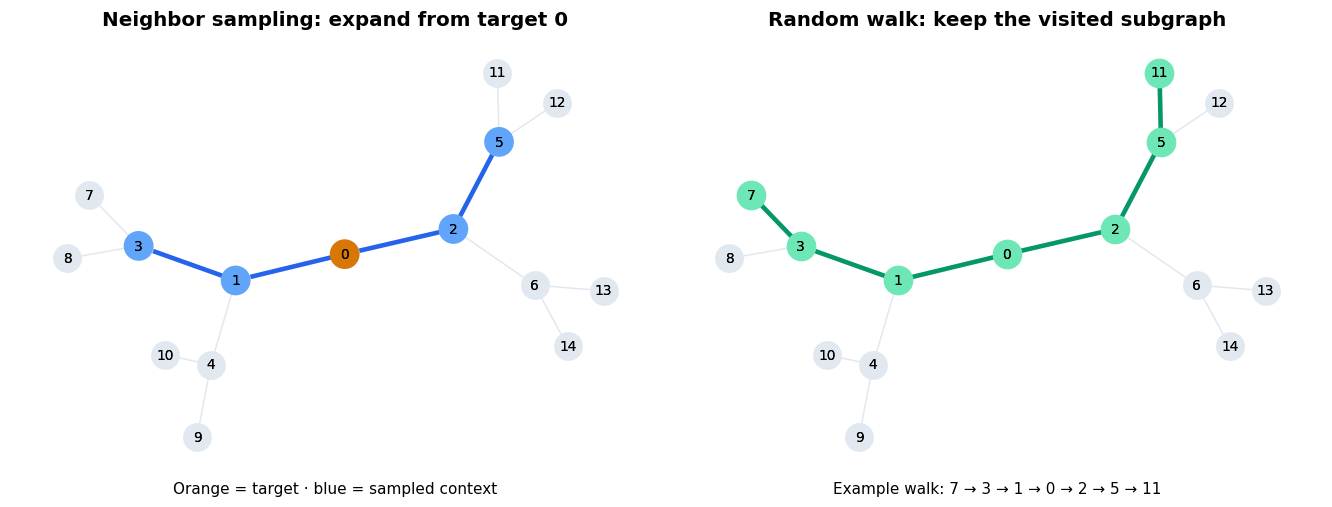

In [6]:
toy = nx.balanced_tree(r=2, h=3)
positions = nx.spring_layout(toy, seed=7)
neighbor_nodes = {0, 1, 2, 3, 5}
neighbor_edges = [(0, 1), (0, 2), (1, 3), (2, 5)]
walk_path = [7, 3, 1, 0, 2, 5, 11]
walk_nodes = set(walk_path)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax in axes:
    nx.draw_networkx(toy, positions, ax=ax, node_color="#e2e8f0", edge_color="#e2e8f0",
                     node_size=320, font_size=9)
    ax.axis("off")
nx.draw_networkx_edges(toy, positions, edgelist=neighbor_edges, ax=axes[0],
                       edge_color="#2563eb", width=3)
nx.draw_networkx_nodes(toy, positions, nodelist=sorted(neighbor_nodes), ax=axes[0],
                       node_color=["#d97706" if n == 0 else "#60a5fa" for n in sorted(neighbor_nodes)],
                       node_size=340)
nx.draw_networkx_labels(toy, positions, ax=axes[0], font_size=9)
axes[0].set_title("Neighbor sampling: expand from target 0")
axes[0].text(0.5, -0.04, "Orange = target · blue = sampled context", transform=axes[0].transAxes, ha="center")
nx.draw_networkx_edges(toy.subgraph(walk_nodes), positions, ax=axes[1], edge_color="#059669", width=3)
nx.draw_networkx_nodes(toy, positions, nodelist=walk_path, ax=axes[1], node_color="#6ee7b7", node_size=340)
nx.draw_networkx_labels(toy, positions, ax=axes[1], font_size=9)
axes[1].set_title("Random walk: keep the visited subgraph")
axes[1].text(0.5, -0.04, "Example walk: 7 → 3 → 1 → 0 → 2 → 5 → 11", transform=axes[1].transAxes, ha="center")
plt.show()


<a id="sage"></a>
## 4 · GraphSAGE: learn useful node embeddings

GraphSAGE combines a node's own features with an aggregation of its neighbors' features:

$$h_v^{(k+1)} = W_{\mathrm{self}}h_v^{(k)} + W_{\mathrm{neighbor}}\,\mathrm{mean}_{u\in\mathcal{N}(v)}h_u^{(k)}.$$

This experiment follows the original notebook's **unsupervised objective**. For each anchor node, a one-step walk picks a positive neighbor and a uniform random draw picks a negative node. The model learns to score positives more highly:

$$\mathcal{L} = -\log\sigma(z_v^\top z_{+}) - \log\sigma(-z_v^\top z_{-}).$$

A random negative can occasionally be a real neighbor; this simple objective does not filter those collisions. After each epoch, a separate logistic regression classifier learns from **training labels only**. Validation accuracy selects a checkpoint; test labels are used only at the end.

**Data flow:** anchor / positive / negative nodes → sampled neighborhoods → 64-dimensional embeddings → structure loss. The label classifier is a separate step.


In [7]:
class ContrastiveNeighborSampler(RawNeighborSampler):
    def sample(self, batch):
        anchors = torch.as_tensor(batch, dtype=torch.long)
        row, col, _ = self.adj_t.coo()
        positives = random_walk(row, col, anchors, walk_length=1, coalesced=False)[:, 1]
        # Isolated nodes cannot take a walk: use the anchor as a fallback.
        positives = torch.where(positives >= 0, positives, anchors)
        negatives = torch.randint(self.adj_t.size(0), (anchors.numel(),))
        seeds = torch.cat([anchors, positives, negatives])
        return super().sample(seeds)


seed_everything()
sage_loader = ContrastiveNeighborSampler(
    cora.edge_index, sizes=FANOUTS, batch_size=BATCH_SIZE,
    shuffle=True, num_nodes=cora.num_nodes, num_workers=0,
)
seed_count, node_ids, blocks = next(iter(sage_loader))
display(pd.DataFrame([
    {"Layer": i + 1, "Source nodes": block.size[0], "Target nodes": block.size[1],
     "Sampled edges": block.edge_index.size(1)}
    for i, block in enumerate(blocks)
]))
print(f"{seed_count // 3} anchors × 3 roles = {seed_count} output embeddings")
print(f"{node_ids.numel()} node entries supply the sampled computation.")


,Layer,Source nodes,Target nodes,Sampled edges
0,1,2474,1849,7782
1,2,1849,768,3254


256 anchors × 3 roles = 768 output embeddings
2474 node entries supply the sampled computation.


**Read the batch table:** blocks are returned in computation order. The first layer gathers information for the second layer's inputs. Target nodes appear first in each block, so `x[:size[1]]` selects their features. The final output preserves the anchor, positive, negative ordering.


In [8]:
class SAGEEncoder(nn.Module):
    def __init__(self, input_channels, hidden_channels, num_layers):
        super().__init__()
        self.convs = nn.ModuleList([
            SAGEConv(input_channels if i == 0 else hidden_channels, hidden_channels)
            for i in range(num_layers)
        ])

    def forward(self, x, blocks):
        for i, (edge_index, _, size) in enumerate(blocks):
            x = self.convs[i]((x, x[:size[1]]), edge_index)
            if i < len(self.convs) - 1:
                x = F.dropout(F.relu(x), p=0.5, training=self.training)
        return x

    def full_forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:
                x = F.dropout(F.relu(x), p=0.5, training=self.training)
        return x


seed_everything()
sage_model = SAGEEncoder(cora.num_node_features, HIDDEN_CHANNELS, len(FANOUTS)).to(DEVICE)
sage_optimizer = torch.optim.Adam(sage_model.parameters(), lr=0.01)
cora_x = cora.x.to(DEVICE)
cora_edges = cora.edge_index.to(DEVICE)


def train_sage_epoch():
    sage_model.train()
    loss_sum = anchor_count = 0
    for seed_count, node_ids, blocks in sage_loader:
        sage_optimizer.zero_grad()
        embeddings = sage_model(cora_x[node_ids.to(DEVICE)], [b.to(DEVICE) for b in blocks])
        anchors, positives, negatives = embeddings.chunk(3, dim=0)
        loss = -F.logsigmoid((anchors * positives).sum(-1)).mean()
        loss -= F.logsigmoid(-(anchors * negatives).sum(-1)).mean()
        loss.backward()
        sage_optimizer.step()
        loss_sum += loss.item() * anchors.size(0)
        anchor_count += anchors.size(0)
    return loss_sum / anchor_count


@torch.no_grad()
def sage_embeddings():
    sage_model.eval()
    return sage_model.full_forward(cora_x, cora_edges).cpu().numpy()


sage_history = []
sage_best = None
started = time.perf_counter()
for epoch in range(1, SAGE_EPOCHS + 1):
    loss = train_sage_epoch()
    embeddings = sage_embeddings()
    probe = LogisticRegression(max_iter=2000, random_state=SEED)
    probe.fit(embeddings[cora.train_mask.numpy()], cora.y[cora.train_mask].numpy())
    val_accuracy = probe.score(embeddings[cora.val_mask.numpy()], cora.y[cora.val_mask].numpy())
    sage_history.append({"epoch": epoch, "loss": loss, "validation": val_accuracy})
    if sage_best is None or val_accuracy > sage_best["validation"]:
        sage_best = {"epoch": epoch, "validation": val_accuracy,
                     "state": deepcopy(sage_model.state_dict()), "probe": deepcopy(probe)}
    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | structure loss {loss:.3f} | validation {val_accuracy:.1%}")
sage_seconds = time.perf_counter() - started
sage_model.load_state_dict(sage_best["state"])
sage_z = sage_embeddings()
print(f"Selected epoch {sage_best['epoch']} using validation accuracy.")


Epoch 01 | structure loss 1.387 | validation 32.6%


Epoch 10 | structure loss 1.013 | validation 68.0%


Epoch 20 | structure loss 0.933 | validation 69.8%


Epoch 30 | structure loss 0.909 | validation 69.0%
Selected epoch 25 using validation accuracy.


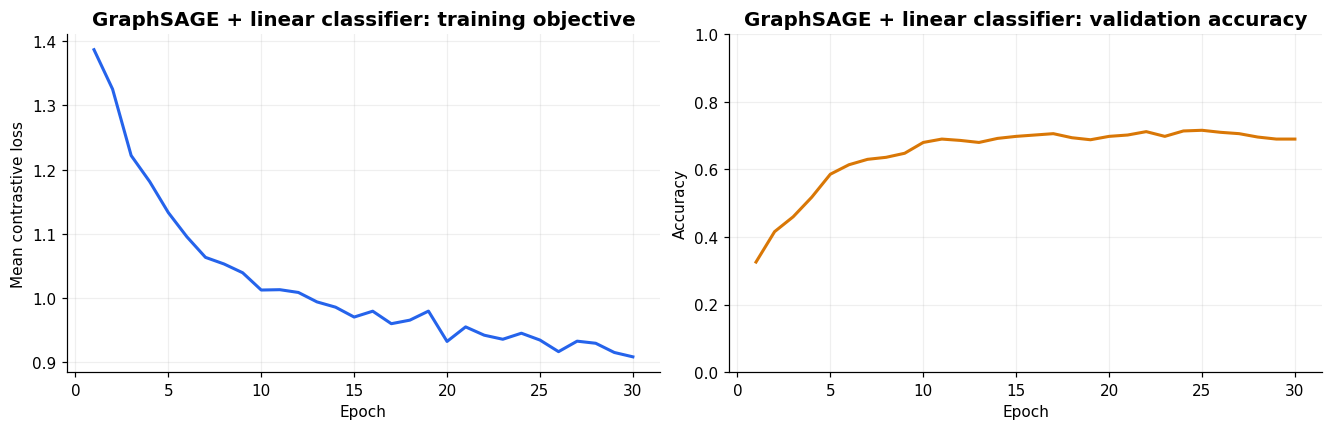

In [9]:
def plot_learning_curves(history, title, loss_label):
    frame = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), constrained_layout=True)
    axes[0].plot(frame.epoch, frame.loss, color="#2563eb", linewidth=2)
    axes[0].set(title=f"{title}: training objective", xlabel="Epoch", ylabel=loss_label)
    axes[1].plot(frame.epoch, frame.validation, color="#d97706", linewidth=2)
    axes[1].set(title=f"{title}: validation accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1))
    for ax in axes:
        ax.grid(alpha=0.2)
    plt.show()


plot_learning_curves(sage_history, "GraphSAGE + linear classifier", "Mean contrastive loss")


**What to look for:** lower structure loss means the embedding objective is improving. It does not guarantee better topic prediction: the encoder never sees topic labels. The right-hand plot measures how useful its embeddings are to the label classifier.

The next plot projects the selected model's embeddings to two dimensions using PCA. **PCA is a visualization, not an accuracy metric.** It discards information, and the topic colors are added only after projection.


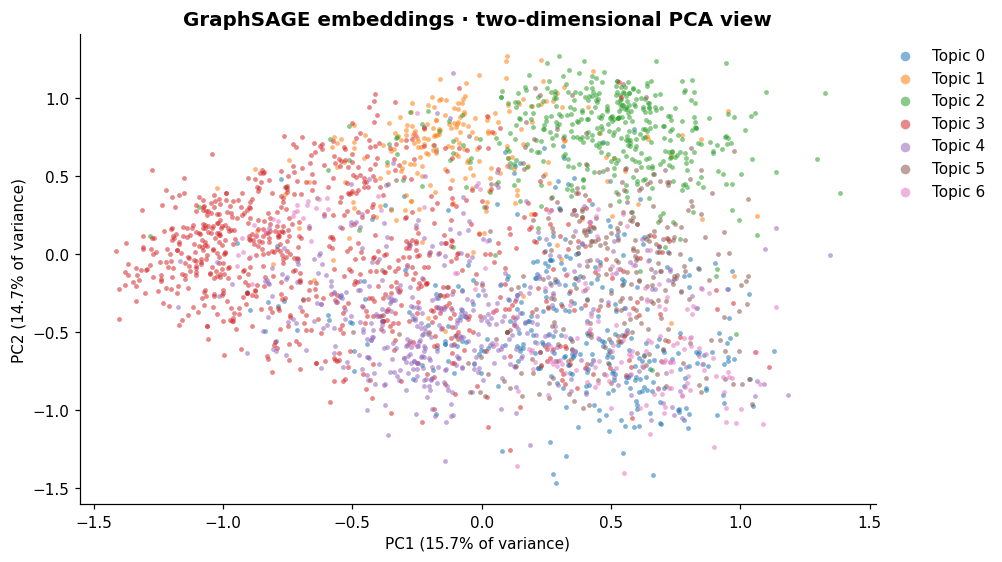

In [10]:
pca = PCA(n_components=2, random_state=SEED)
coordinates = pca.fit_transform(sage_z)
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
for label, name in enumerate(CLASS_NAMES):
    mask = cora.y.numpy() == label
    ax.scatter(coordinates[mask, 0], coordinates[mask, 1], s=10, alpha=0.55,
               label=name, color=plt.get_cmap("tab10")(label), linewidths=0)
ax.set(title="GraphSAGE embeddings · two-dimensional PCA view",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} of variance)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} of variance)")
ax.legend(markerscale=2, bbox_to_anchor=(1, 1), loc="upper left", frameon=False)
plt.show()


<a id="saint"></a>
## 5 · GraphSAINT: train on random-walk subgraphs

GraphSAINT is a **sampling method**, not a particular neural network layer. Here it supplies small subgraphs to a three-layer `GraphConv` classifier. Hidden states from all three layers are concatenated before classification.

**Data flow:** random-walk roots → sampled subgraph → three graph convolutions → class scores → loss on sampled training nodes.

The default uses mean aggregation and ordinary cross-entropy, a simplified sampled-subgraph baseline. Set `USE_SAINT_NORMALIZATION = True` in the settings and rerun to use GraphSAINT's estimated sampling corrections: `edge_norm` adjusts sampled messages and `node_norm` weights the loss. That branch uses additive aggregation and inverse in-degree edge weights, including the same base edge weights during full-graph evaluation.

Validation always runs on the full Cora graph. This is convenient for a small lesson; a large graph needs a separate scalable inference strategy.


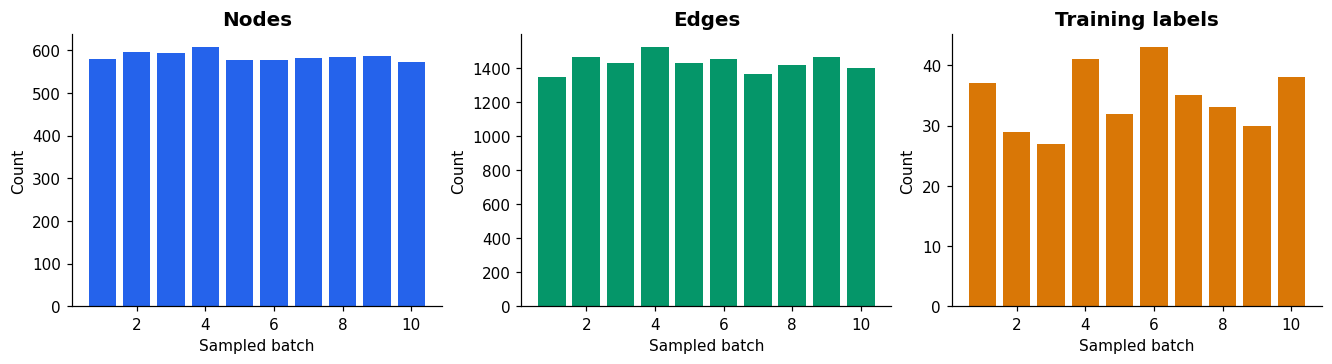

Random walks produce variable-size batches; training labels are only a subset of sampled nodes.


In [11]:
seed_everything()
saint_data = cora.clone()
saint_data.node_id = torch.arange(cora.num_nodes)
destination = saint_data.edge_index[1]
saint_data.edge_weight = degree(destination, saint_data.num_nodes).clamp_min(1).reciprocal()[destination]
saint_loader = GraphSAINTRandomWalkSampler(
    saint_data, batch_size=BATCH_SIZE, walk_length=SAINT_WALK_LENGTH,
    num_steps=SAINT_STEPS,
    sample_coverage=20 if USE_SAINT_NORMALIZATION else 0,
    num_workers=0, log=False,
)

batch_records = []
for batch in saint_loader:
    batch_records.append({"Nodes": batch.num_nodes, "Edges": batch.num_edges,
                          "Training labels": int(batch.train_mask.sum())})
batch_frame = pd.DataFrame(batch_records)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)
for ax, column, color in zip(axes, batch_frame.columns, ["#2563eb", "#059669", "#d97706"]):
    ax.bar(np.arange(1, len(batch_frame) + 1), batch_frame[column], color=color)
    ax.set(title=column, xlabel="Sampled batch", ylabel="Count")
plt.show()
print("Random walks produce variable-size batches; training labels are only a subset of sampled nodes.")


Epoch 01 | batch loss 1.946 | validation 16.2%


Epoch 10 | batch loss 1.037 | validation 67.2%


Epoch 20 | batch loss 0.055 | validation 75.6%


Epoch 30 | batch loss 0.015 | validation 76.0%


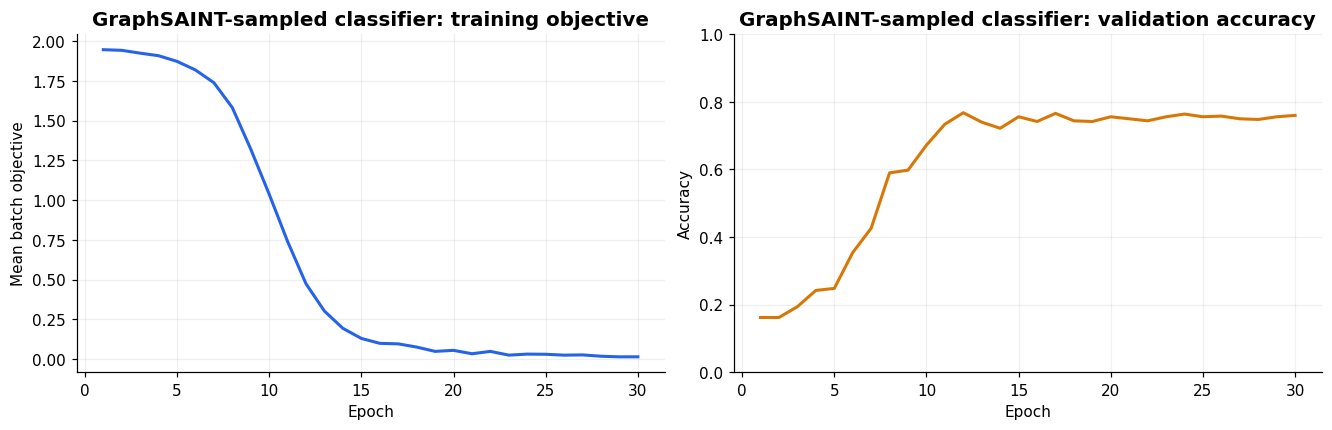

Selected epoch 12 using validation accuracy.


In [12]:
class SAINTClassifier(nn.Module):
    def __init__(self, input_channels, hidden_channels, num_classes, normalized=False):
        super().__init__()
        # Configure aggregation at construction; do not mutate it between passes.
        aggregation = "add" if normalized else "mean"
        self.convs = nn.ModuleList([
            GraphConv(input_channels if i == 0 else hidden_channels,
                      hidden_channels, aggr=aggregation)
            for i in range(3)
        ])
        self.classifier = nn.Linear(3 * hidden_channels, num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        hidden_states = []
        for conv in self.convs:
            x = F.dropout(F.relu(conv(x, edge_index, edge_weight)), p=0.2, training=self.training)
            hidden_states.append(x)
        return self.classifier(torch.cat(hidden_states, dim=-1))


seed_everything()
saint_model = SAINTClassifier(cora.num_node_features, HIDDEN_CHANNELS, NUM_CLASSES,
                              normalized=USE_SAINT_NORMALIZATION).to(DEVICE)
saint_optimizer = torch.optim.Adam(saint_model.parameters(), lr=0.001)


def train_saint_epoch():
    saint_model.train()
    losses = []
    for sampled in saint_loader:
        if not sampled.train_mask.any():
            continue  # A sampled subgraph may contain no supervised targets.
        sampled = sampled.to(DEVICE)
        saint_optimizer.zero_grad()
        weights = sampled.edge_norm * sampled.edge_weight if USE_SAINT_NORMALIZATION else None
        logits = saint_model(sampled.x, sampled.edge_index, weights)
        if USE_SAINT_NORMALIZATION:
            per_node = F.cross_entropy(logits, sampled.y.view(-1), reduction="none")
            loss = (per_node * sampled.node_norm)[sampled.train_mask].sum()
        else:
            loss = F.cross_entropy(logits[sampled.train_mask], sampled.y.view(-1)[sampled.train_mask])
        loss.backward()
        saint_optimizer.step()
        losses.append(loss.item())
    if not losses:
        raise RuntimeError("No training labels sampled. Increase BATCH_SIZE or SAINT_STEPS.")
    return float(np.mean(losses))


@torch.no_grad()
def saint_predictions():
    saint_model.eval()
    weights = saint_data.edge_weight.to(DEVICE) if USE_SAINT_NORMALIZATION else None
    return saint_model(cora_x, cora_edges, weights).argmax(dim=-1).cpu()


saint_history = []
saint_best = None
started = time.perf_counter()
for epoch in range(1, SAINT_EPOCHS + 1):
    loss = train_saint_epoch()
    predictions = saint_predictions()
    val_accuracy = float((predictions[cora.val_mask] == cora.y[cora.val_mask]).float().mean())
    saint_history.append({"epoch": epoch, "loss": loss, "validation": val_accuracy})
    if saint_best is None or val_accuracy > saint_best["validation"]:
        saint_best = {"epoch": epoch, "validation": val_accuracy,
                      "state": deepcopy(saint_model.state_dict())}
    if epoch == 1 or epoch % 10 == 0:
        print(f"Epoch {epoch:02d} | batch loss {loss:.3f} | validation {val_accuracy:.1%}")
saint_seconds = time.perf_counter() - started
saint_model.load_state_dict(saint_best["state"])
plot_learning_curves(saint_history, "GraphSAINT-sampled classifier", "Mean batch objective")
print(f"Selected epoch {saint_best['epoch']} using validation accuracy.")


### Further reading

<!-- | Symptom | What to check |
|:--|:--|
| `torch_sparse` / `torch_cluster` import fails | Match extension wheels to the installed PyTorch and CUDA versions; restart the kernel after installation. |
| Dataset download fails | The first Cora run needs network access. Later runs reuse `DATA_ROOT`. |
| A sampled batch has no training labels | The training loop skips it. Increase the number of roots or steps if an entire epoch has no labels. |
| Labels have shape `[N, 1]` | Use `.view(-1)` before loss and accuracy computation to avoid broadcasting or single-node squeeze errors. |
| Optional OGB loading fails | Check the OGB/PyTorch versions and the reported safe-loading type. The Cora lesson is independent of this extension. | -->

- [GraphSAGE paper](https://arxiv.org/abs/1706.02216): learning representations by sampling and aggregating neighborhoods.
- [GraphSAINT paper](https://arxiv.org/abs/1907.04931): training with sampled subgraphs and sampling normalization.
- [PyG sampler documentation](https://pytorch-geometric.readthedocs.io/en/2.6.1/modules/loader.html): loader arguments and sampled data fields.
- [PyG installation guide](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html): compatible binary dependencies.
